# 01 — Raw Data Exploration

Goal: understand what each raw file looks like **before any cleaning**, and identify what processing is needed.

Sections:
1. Day-ahead prices
2. Weather (Open-Meteo)
3. Actual load (ENTSO-E)
4. Load forecast (ENTSO-E)
5. Generation mix (ENTSO-E)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

RAW = Path('../../Data/raw')

plt.rcParams.update({'figure.figsize': (14, 4), 'axes.grid': True, 'grid.alpha': 0.3})


def print_summary(df, label):
    print(f'=== {label} ===')
    print(f'Rows       : {len(df):,}')
    if hasattr(df.index, 'min') and pd.api.types.is_datetime64_any_dtype(df.index):
        print(f'Date range : {df.index.min()} → {df.index.max()}')
        diffs = df.index.to_series().diff().dropna()
        print(f'Resolution : {diffs.mode()[0]} (most common gap)')
    print(f'Columns    : {list(df.columns)}')
    print(f'Dtypes:\n{df.dtypes.to_string()}')
    print(f'Missing values per column:')
    print(df.isnull().sum().to_string())
    print()

---
## 1 — Day-ahead prices

Five annual CSV files: `Netherlands_2021.csv` … `Netherlands_2025.csv`.

In [2]:
price_dir = RAW / 'manual' / 'day_ahead_prices'
price_files = sorted(price_dir.glob('Netherlands_*.csv'))
print('Files found:', [f.name for f in price_files])

# Load each file individually so we can see per-file row counts
price_frames = []
for f in price_files:
    df_year = pd.read_csv(f)
    print(f'{f.name}: {len(df_year):,} rows')
    price_frames.append(df_year)

# Concatenate raw (no index parsing yet)
prices_raw = pd.concat(price_frames, ignore_index=True)

# Set datetime index for summary
prices_raw['Datetime (UTC)'] = pd.to_datetime(prices_raw['Datetime (UTC)'])
prices_raw = prices_raw.set_index('Datetime (UTC)')

print_summary(prices_raw, 'Day-ahead prices (raw concat)')

Files found: ['Netherlands_2021.csv', 'Netherlands_2022.csv', 'Netherlands_2023.csv', 'Netherlands_2024.csv', 'Netherlands_2025.csv']
Netherlands_2021.csv: 8,760 rows
Netherlands_2022.csv: 8,760 rows
Netherlands_2023.csv: 8,760 rows
Netherlands_2024.csv: 8,784 rows
Netherlands_2025.csv: 8,760 rows
=== Day-ahead prices (raw concat) ===
Rows       : 43,824
Date range : 2021-01-01 00:00:00 → 2025-12-31 23:00:00
Resolution : 0 days 01:00:00 (most common gap)
Columns    : ['Country', 'ISO3 Code', 'Datetime (Local)', 'Price (EUR/kWhe)']
Dtypes:
Country                 str
ISO3 Code               str
Datetime (Local)        str
Price (EUR/kWhe)    float64
Missing values per column:
Country             0
ISO3 Code           0
Datetime (Local)    0
Price (EUR/kWhe)    0



In [3]:
print('First 3 rows:')
display(prices_raw.head(3))
print('Last 3 rows:')
display(prices_raw.tail(3))

First 3 rows:


,Country,ISO3 Code,Datetime (Local),Price (EUR/kWhe)
Datetime (UTC),,,,
2021-01-01 00:00:00,Netherlands,NLD,2021-01-01 01:00:00,0.04819
2021-01-01 01:00:00,Netherlands,NLD,2021-01-01 02:00:00,0.04468
2021-01-01 02:00:00,Netherlands,NLD,2021-01-01 03:00:00,0.04292


Last 3 rows:


,Country,ISO3 Code,Datetime (Local),Price (EUR/kWhe)
Datetime (UTC),,,,
2025-12-31 21:00:00,Netherlands,NLD,2025-12-31 22:00:00,0.08205
2025-12-31 22:00:00,Netherlands,NLD,2025-12-31 23:00:00,0.07261
2025-12-31 23:00:00,Netherlands,NLD,2026-01-01 00:00:00,0.06344


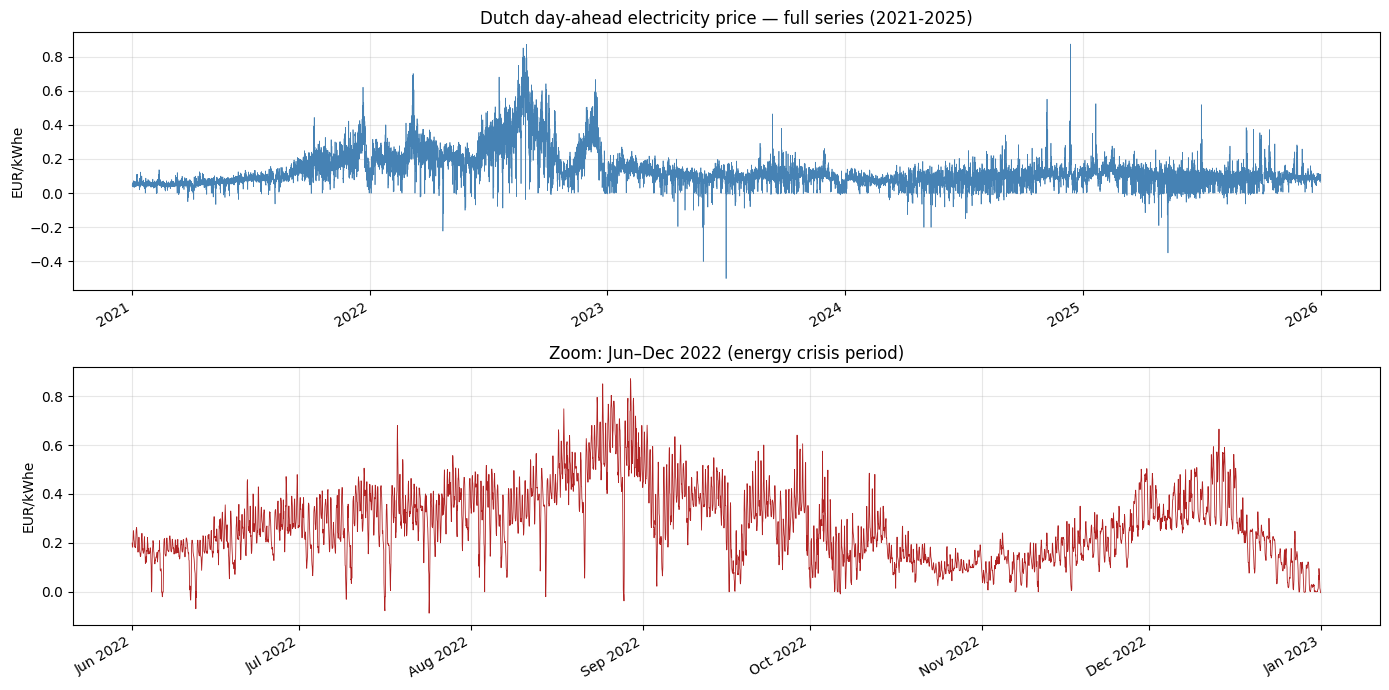

Price distribution (EUR/kWhe):


count    43824.000000
mean         0.120937
std          0.098852
min         -0.500000
25%          0.067980
50%          0.097000
75%          0.144500
max          0.872960
Name: Price (EUR/kWhe), dtype: float64

Negative prices: 1513


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(prices_raw.index, prices_raw['Price (EUR/kWhe)'], linewidth=0.5, color='steelblue')
axes[0].set_title('Dutch day-ahead electricity price — full series (2021-2025)')
axes[0].set_ylabel('EUR/kWhe')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Zoom: 2022 energy crisis
crisis = prices_raw['2022-06':'2022-12']
axes[1].plot(crisis.index, crisis['Price (EUR/kWhe)'], linewidth=0.6, color='firebrick')
axes[1].set_title('Zoom: Jun–Dec 2022 (energy crisis period)')
axes[1].set_ylabel('EUR/kWhe')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

for ax in axes:
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print('Price distribution (EUR/kWhe):')
display(prices_raw['Price (EUR/kWhe)'].describe())
print(f"Negative prices: {(prices_raw['Price (EUR/kWhe)'] < 0).sum()}")

### Issues — Day-ahead prices

| # | Issue | Action needed |
|---|-------|---------------|
| 1 | Five separate annual files | Concatenate into one DataFrame |
| 2 | `Datetime (UTC)` stored as string | Parse to `datetime64`, set as index |
| 3 | `Country` and `ISO3 Code` columns are constant | Drop them (no information) |
| 4 | `Datetime (Local)` is CET — two different offsets (CET +01 / CEST +02) | Drop; use UTC index only |
| 5 | Index has no `tz` attribute after parsing | Localize to `UTC` so joins with other sources work |
| 6 | Negative prices exist (curtailment events) | Keep as-is; flag count in QA report |
| 7 | Check for gaps or duplicates around DST transitions | Verify row count = expected hours per year |

---
## 2 — Weather

Single file: `open-meteo-2021-2025.csv`. Has 3 metadata rows at the top before the actual header.

In [5]:
meteo_path = RAW / 'manual' / 'meteo' / 'open-meteo-2021-2025.csv'

# Show the raw first 5 lines so we can see the metadata rows
print('Raw first 5 lines:')
with open(meteo_path) as fh:
    for i, line in enumerate(fh):
        if i >= 5:
            break
        print(f'  [{i}] {line}', end='')

Raw first 5 lines:
  [0] latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
  [1] 52.126537,5.1381216,3.0,0,GMT,GMT
  [2] 
  [3] time,temperature_2m (°C),wind_speed_10m (km/h),wind_speed_100m (km/h),cloud_cover (%),shortwave_radiation (W/m²),direct_radiation (W/m²)
  [4] 2021-01-01T00:00,0.1,5.9,13.9,40,0.0,0.0


In [6]:
# Load with no cleaning: row 0 is the metadata row we want to see,
# row 3 is the actual header, data starts at row 4.
meteo_raw = pd.read_csv(meteo_path, skiprows=3)
meteo_raw['time'] = pd.to_datetime(meteo_raw['time'])
meteo_raw = meteo_raw.set_index('time')

print_summary(meteo_raw, 'Weather (raw)')

=== Weather (raw) ===
Rows       : 43,824
Date range : 2021-01-01 00:00:00 → 2025-12-31 23:00:00
Resolution : 0 days 01:00:00 (most common gap)
Columns    : ['temperature_2m (°C)', 'wind_speed_10m (km/h)', 'wind_speed_100m (km/h)', 'cloud_cover (%)', 'shortwave_radiation (W/m²)', 'direct_radiation (W/m²)']
Dtypes:
temperature_2m (°C)           float64
wind_speed_10m (km/h)         float64
wind_speed_100m (km/h)        float64
cloud_cover (%)                 int64
shortwave_radiation (W/m²)    float64
direct_radiation (W/m²)       float64
Missing values per column:
temperature_2m (°C)           0
wind_speed_10m (km/h)         0
wind_speed_100m (km/h)        0
cloud_cover (%)               0
shortwave_radiation (W/m²)    0
direct_radiation (W/m²)       0



In [7]:
print('First 3 rows:')
display(meteo_raw.head(3))

First 3 rows:


,temperature_2m (°C),wind_speed_10m (km/h),wind_speed_100m (km/h),cloud_cover (%),shortwave_radiation (W/m²),direct_radiation (W/m²)
time,,,,,,
2021-01-01 00:00:00,0.1,5.9,13.9,40,0.0,0.0
2021-01-01 01:00:00,0.6,6.2,16.6,83,0.0,0.0
2021-01-01 02:00:00,0.7,5.5,14.2,54,0.0,0.0


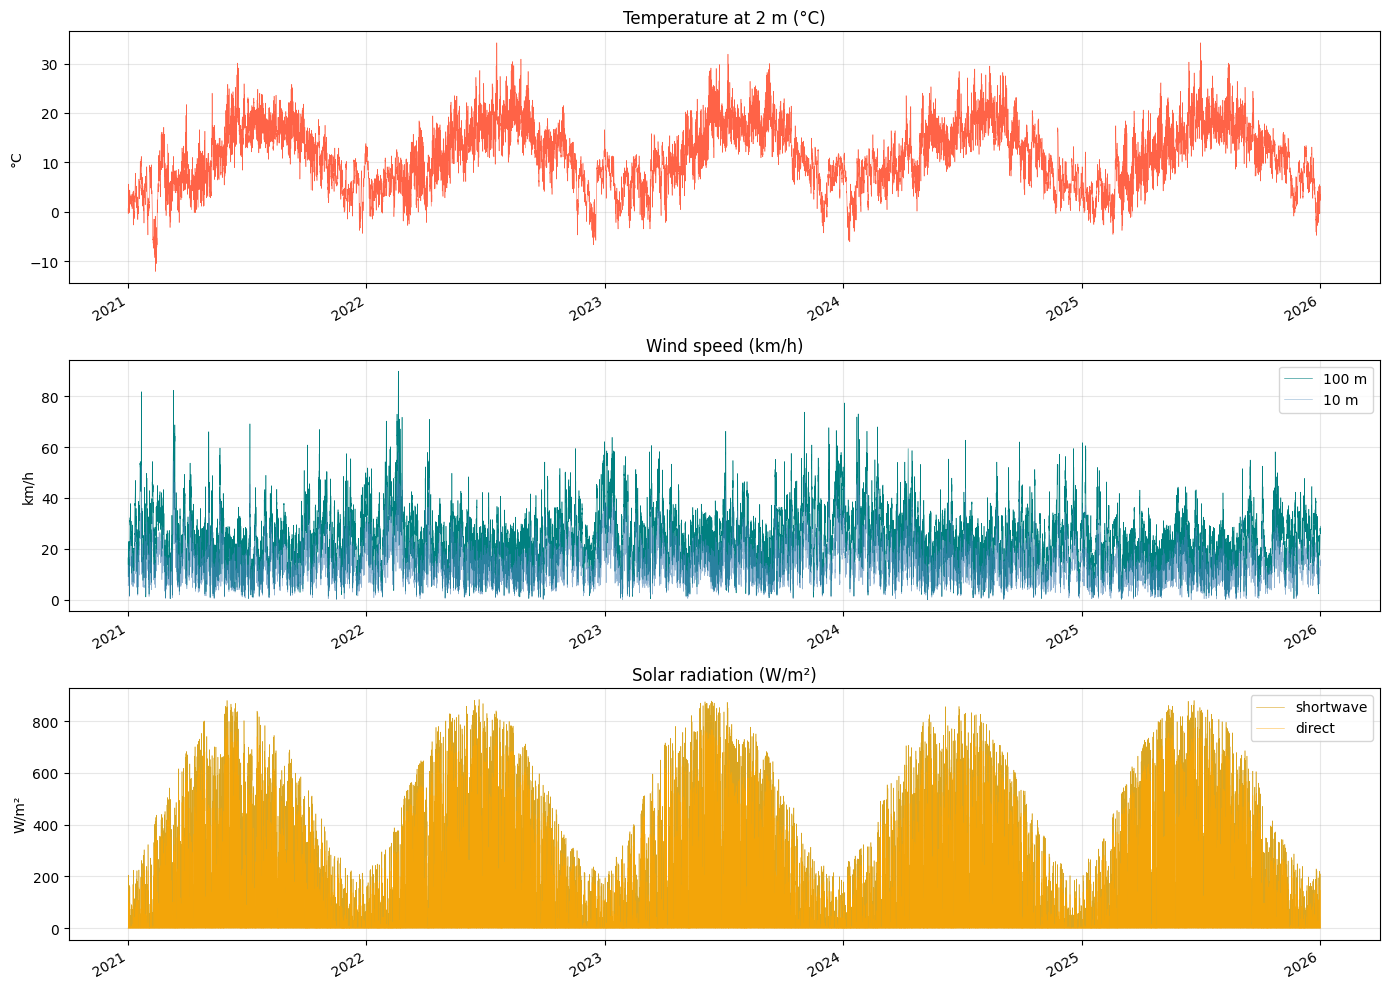

Descriptive statistics:


,temperature_2m (°C),wind_speed_10m (km/h),wind_speed_100m (km/h),cloud_cover (%),shortwave_radiation (W/m²),direct_radiation (W/m²)
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,11.240841,13.896947,23.835282,67.540982,131.853459,78.034684
std,6.478815,6.978385,10.684385,38.930794,203.382568,150.127100
min,-12.100000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.600000,8.700000,16.400000,29.000000,0.000000,0.000000
50%,11.100000,12.800000,22.900000,94.000000,5.000000,0.000000
75%,16.000000,17.900000,30.000000,100.000000,203.000000,79.000000
max,34.200000,57.800000,89.800000,100.000000,884.000000,777.000000


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(meteo_raw.index, meteo_raw['temperature_2m (°C)'], linewidth=0.4, color='tomato')
axes[0].set_title('Temperature at 2 m (°C)')
axes[0].set_ylabel('°C')

axes[1].plot(meteo_raw.index, meteo_raw['wind_speed_100m (km/h)'], linewidth=0.4, color='teal', label='100 m')
axes[1].plot(meteo_raw.index, meteo_raw['wind_speed_10m (km/h)'], linewidth=0.4, color='steelblue', alpha=0.6, label='10 m')
axes[1].set_title('Wind speed (km/h)')
axes[1].set_ylabel('km/h')
axes[1].legend()

axes[2].plot(meteo_raw.index, meteo_raw['shortwave_radiation (W/m²)'], linewidth=0.4, color='goldenrod', label='shortwave')
axes[2].plot(meteo_raw.index, meteo_raw['direct_radiation (W/m²)'], linewidth=0.4, color='orange', alpha=0.7, label='direct')
axes[2].set_title('Solar radiation (W/m²)')
axes[2].set_ylabel('W/m²')
axes[2].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print('Descriptive statistics:')
display(meteo_raw.describe())

### Issues — Weather

| # | Issue | Action needed |
|---|-------|---------------|
| 1 | File has 3 metadata rows (lat, lon, elevation, etc.) before the column header | Use `skiprows=3` when loading |
| 2 | `time` column is a string without timezone info; `utc_offset_seconds=0` in metadata confirms UTC | Parse and localize to UTC |
| 3 | Column names include units in parentheses (`temperature_2m (°C)`) | Rename to clean snake_case (`temperature_2m`) |
| 4 | Verify row count = expected hourly rows for 2021-01-01 → 2025-xx-xx | Check for gaps |
| 5 | `cloud_cover (%)` has no obvious cleaning issue but verify range 0-100 | Assert bounds |

---
## 3 — Actual load

File: `entso_e/nl_actual_load.csv`. 15-minute resolution, CET timezone.

In [9]:
load_path = RAW / 'entso_e' / 'nl_actual_load.csv'

# Load raw: first column is the timestamp index (unnamed)
load_raw = pd.read_csv(load_path, index_col=0)

print('Dtype of index before parsing:', load_raw.index.dtype)
print('First 3 index values:', load_raw.index[:3].tolist())

# Parse the timezone-aware index as-is
load_raw.index = pd.to_datetime(load_raw.index, utc=True)

print_summary(load_raw, 'Actual load (raw)')

Dtype of index before parsing: str
First 3 index values: ['2021-01-01 00:00:00+01:00', '2021-01-01 00:15:00+01:00', '2021-01-01 00:30:00+01:00']
=== Actual load (raw) ===
Rows       : 175,292
Date range : 2020-12-31 23:00:00+00:00 → 2025-12-31 22:45:00+00:00
Resolution : 0 days 00:15:00 (most common gap)
Columns    : ['Actual Load']
Dtypes:
Actual Load    float64
Missing values per column:
Actual Load    0



In [10]:
print('First 3 rows:')
display(load_raw.head(3))
print('\nIndex timezone:', load_raw.index.tz)

First 3 rows:


,Actual Load
2020-12-31 23:00:00+00:00,11394.82
2020-12-31 23:15:00+00:00,11432.82
2020-12-31 23:30:00+00:00,11434.49



Index timezone: UTC


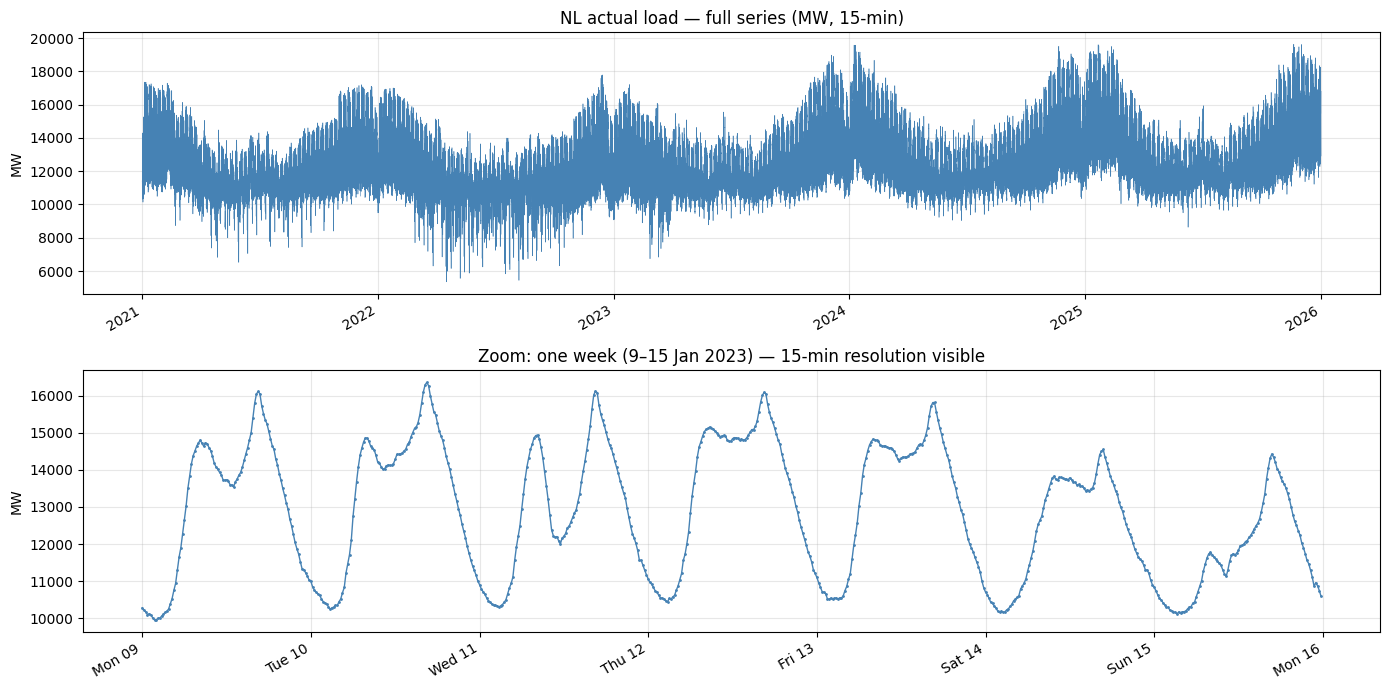

Actual Load (MW) stats:


count    175292.000000
mean      12507.286594
std        2049.041588
min        5349.570000
25%       10966.582500
50%       12317.221000
75%       13759.052500
max       19631.971000
Name: Actual Load, dtype: float64

Zero or negative values: 0


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(load_raw.index, load_raw['Actual Load'], linewidth=0.4, color='steelblue')
axes[0].set_title('NL actual load — full series (MW, 15-min)')
axes[0].set_ylabel('MW')

# Zoom: one week
week = load_raw['2023-01-09':'2023-01-15']
axes[1].plot(week.index, week['Actual Load'], linewidth=1, color='steelblue', marker='.', markersize=2)
axes[1].set_title('Zoom: one week (9–15 Jan 2023) — 15-min resolution visible')
axes[1].set_ylabel('MW')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))

for ax in axes:
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print('Actual Load (MW) stats:')
display(load_raw['Actual Load'].describe())
print(f"Zero or negative values: {(load_raw['Actual Load'] <= 0).sum()}")

### Issues — Actual load

| # | Issue | Action needed |
|---|-------|---------------|
| 1 | Index is CET (`+01:00`) — pandas reads this as UTC+1, not UTC | Convert to UTC: `tz_convert('UTC')` |
| 2 | Resolution is 15-minute; ML features need hourly | Resample to hourly mean |
| 3 | Index column has no name (empty header in CSV) | Rename to `datetime_utc` after parsing |
| 4 | DST transitions in CET mean two ambiguous hours per year | Check for duplicated or missing timestamps at DST boundaries |
| 5 | Check for gaps in 15-min series (e.g. maintenance outages) | Report any runs of missing rows |

---
## 4 — Load forecast

File: `entso_e/nl_load_forecast.csv`. Same structure as actual load.

In [12]:
fcst_path = RAW / 'entso_e' / 'nl_load_forecast.csv'

fcst_raw = pd.read_csv(fcst_path, index_col=0)
fcst_raw.index = pd.to_datetime(fcst_raw.index, utc=True)

print_summary(fcst_raw, 'Load forecast (raw)')

=== Load forecast (raw) ===
Rows       : 175,292
Date range : 2020-12-31 23:00:00+00:00 → 2025-12-31 22:45:00+00:00
Resolution : 0 days 00:15:00 (most common gap)
Columns    : ['Forecasted Load']
Dtypes:
Forecasted Load    float64
Missing values per column:
Forecasted Load    0



In [13]:
print('First 3 rows:')
display(fcst_raw.head(3))

First 3 rows:


,Forecasted Load
2020-12-31 23:00:00+00:00,12450.64
2020-12-31 23:15:00+00:00,12446.36
2020-12-31 23:30:00+00:00,12406.32


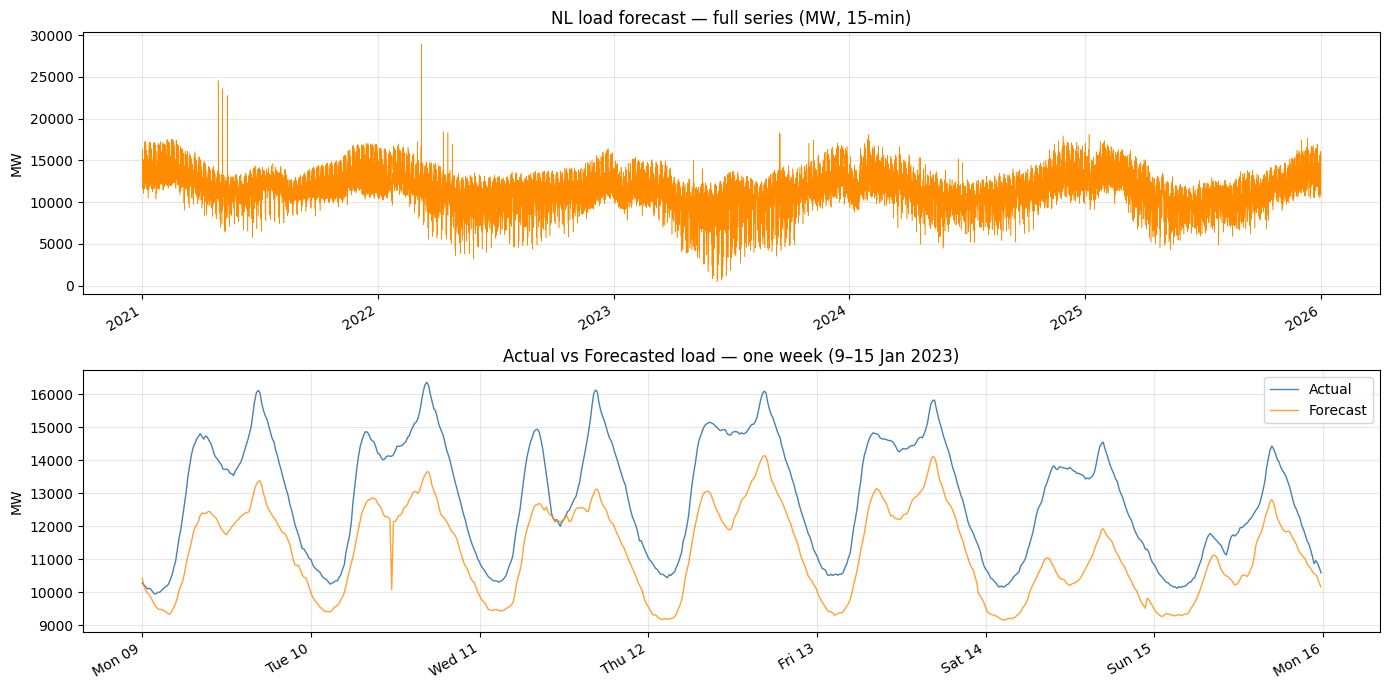

Forecasted Load (MW) stats:


count    175292.000000
mean      11368.047428
std        2236.688755
min         438.540000
25%       10179.715000
50%       11369.482000
75%       12722.142500
max       28898.550000
Name: Forecasted Load, dtype: float64

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(fcst_raw.index, fcst_raw['Forecasted Load'], linewidth=0.4, color='darkorange')
axes[0].set_title('NL load forecast — full series (MW, 15-min)')
axes[0].set_ylabel('MW')

# Overlay actual vs forecast for a shared week
shared_start, shared_end = '2023-01-09', '2023-01-15'
load_week = load_raw[shared_start:shared_end]
fcst_week = fcst_raw[shared_start:shared_end]

axes[1].plot(load_week.index, load_week['Actual Load'], linewidth=1, color='steelblue', label='Actual')
axes[1].plot(fcst_week.index, fcst_week['Forecasted Load'], linewidth=1, color='darkorange', alpha=0.8, label='Forecast')
axes[1].set_title('Actual vs Forecasted load — one week (9–15 Jan 2023)')
axes[1].set_ylabel('MW')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))

for ax in axes:
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print('Forecasted Load (MW) stats:')
display(fcst_raw['Forecasted Load'].describe())

In [15]:
# Date range overlap between actual and forecast
print(f'Actual load  : {load_raw.index.min()} → {load_raw.index.max()}')
print(f'Load forecast: {fcst_raw.index.min()} → {fcst_raw.index.max()}')
overlap_start = max(load_raw.index.min(), fcst_raw.index.min())
overlap_end   = min(load_raw.index.max(), fcst_raw.index.max())
print(f'Overlap      : {overlap_start} → {overlap_end}')

Actual load  : 2020-12-31 23:00:00+00:00 → 2025-12-31 22:45:00+00:00
Load forecast: 2020-12-31 23:00:00+00:00 → 2025-12-31 22:45:00+00:00
Overlap      : 2020-12-31 23:00:00+00:00 → 2025-12-31 22:45:00+00:00


### Issues — Load forecast

| # | Issue | Action needed |
|---|-------|---------------|
| 1 | Same CET timezone as actual load | Convert to UTC |
| 2 | Resolution is 15-minute | Resample to hourly mean |
| 3 | Index column unnamed | Rename to `datetime_utc` |
| 4 | Date range may differ from actual load | Check overlap before joining; align on common index |
| 5 | Forecast may be published ahead of the day (ENTSO-E day-ahead) — timestamps may be shifted | Verify timestamps represent the interval start, not publication time |

---
## 5 — Generation mix

File: `entso_e/nl_generation_mix.csv`. Multi-level columns: fuel type × (Actual Aggregated / Actual Consumption). 15-minute, CET.

In [16]:
genmix_path = RAW / 'entso_e' / 'nl_generation_mix.csv'

# Load with two header rows to preserve the multi-level structure
genmix_raw = pd.read_csv(genmix_path, header=[0, 1], index_col=0)
genmix_raw.index = pd.to_datetime(genmix_raw.index, utc=True)

print('Multi-level columns (fuel × metric):')
print(genmix_raw.columns.tolist())
print()

Multi-level columns (fuel × metric):
[('Biomass', 'Actual Aggregated'), ('Biomass', 'Actual Consumption'), ('Fossil Gas', 'Actual Aggregated'), ('Fossil Gas', 'Actual Consumption'), ('Fossil Hard coal', 'Actual Aggregated'), ('Fossil Hard coal', 'Actual Consumption'), ('Hydro Run-of-river and poundage', 'Actual Aggregated'), ('Hydro Run-of-river and poundage', 'Actual Consumption'), ('Nuclear', 'Actual Aggregated'), ('Nuclear', 'Actual Consumption'), ('Other', 'Actual Aggregated'), ('Other', 'Actual Consumption'), ('Solar', 'Actual Aggregated'), ('Solar', 'Actual Consumption'), ('Waste', 'Actual Aggregated'), ('Waste', 'Actual Consumption'), ('Wind Offshore', 'Actual Aggregated'), ('Wind Offshore', 'Actual Consumption'), ('Wind Onshore', 'Actual Aggregated'), ('Wind Onshore', 'Actual Consumption')]



In [17]:
print(f'Rows       : {len(genmix_raw):,}')
print(f'Date range : {genmix_raw.index.min()} → {genmix_raw.index.max()}')
diffs = genmix_raw.index.to_series().diff().dropna()
print(f'Resolution : {diffs.mode()[0]}')
print(f'Columns    : {len(genmix_raw.columns)} total ({genmix_raw.columns.get_level_values(0).nunique()} fuel types × 2 metrics)')
print()
print('Dtypes:')
print(genmix_raw.dtypes.to_string())
print()
print('Missing values per column:')
print(genmix_raw.isnull().sum().to_string())

Rows       : 175,296
Date range : 2020-12-31 23:00:00+00:00 → 2025-12-31 22:45:00+00:00
Resolution : 0 days 00:15:00
Columns    : 20 total (10 fuel types × 2 metrics)

Dtypes:
Biomass                          Actual Aggregated     float64
                                 Actual Consumption    float64
Fossil Gas                       Actual Aggregated     float64
                                 Actual Consumption    float64
Fossil Hard coal                 Actual Aggregated     float64
                                 Actual Consumption    float64
Hydro Run-of-river and poundage  Actual Aggregated     float64
                                 Actual Consumption    float64
Nuclear                          Actual Aggregated     float64
                                 Actual Consumption    float64
Other                            Actual Aggregated     float64
                                 Actual Consumption    float64
Solar                            Actual Aggregated     float64
     

In [18]:
print('First 3 rows:')
display(genmix_raw.head(3))

First 3 rows:


Biomass                     \
                          Actual Aggregated Actual Consumption   
2020-12-31 23:00:00+00:00             15.20                0.0   
2020-12-31 23:15:00+00:00             16.05                0.0   
2020-12-31 23:30:00+00:00             16.28                0.0   

                                 Fossil Gas                     \
                          Actual Aggregated Actual Consumption   
2020-12-31 23:00:00+00:00           6062.53              75.71   
2020-12-31 23:15:00+00:00           5728.42              72.52   
2020-12-31 23:30:00+00:00           5515.30              68.20   

                           Fossil Hard coal                     \
                          Actual Aggregated Actual Consumption   
2020-12-31 23:00:00+00:00           2110.96              31.28   
2020-12-31 23:15:00+00:00           2077.04              31.24   
2020-12-31 23:30:00+00:00           2062.23              31.64   

                          Hydro Run-of-river and poundage                     \
                                        Actual Aggregated Actual Consumption   
2020-12-31 23:00:00+00:00                             0.0                0.0   
2020-12-31 23:15:00+00:00                             0.0                0.0   
2020-12-31 23:30:00+00:00                             0.0                0.0   

                                    Nuclear                     \
                          Actual Aggregated Actual Consumption   
2020-12-31 23:00:00+00:00            483.81                0.0   
2020-12-31 23:15:00+00:00            483.80                0.0   
2020-12-31 23:30:00+00:00            483.85                0.0   

                                      Other                     \
                          Actual Aggregated Actual Consumption   
2020-12-31 23:00:00+00:00           2120.64            1143.84   
2020-12-31 23:15:00+00:00           1977.27            1203.43   
2020-12-31 23:30:00+00:00           1855.76            1215.15   

                                      Solar                     \
                          Actual Aggregated Actual Consumption   
2020-12-31 23:00:00+00:00               0.0               0.50   
2020-12-31 23:15:00+00:00               0.0               0.52   
2020-12-31 23:30:00+00:00               0.0               0.46   

                                      Waste                     \
                          Actual Aggregated Actual Consumption   
2020-12-31 23:00:00+00:00            418.58                0.0   
2020-12-31 23:15:00+00:00            415.62                0.0   
2020-12-31 23:30:00+00:00            417.66                0.0   

                              Wind Offshore                     \
                          Actual Aggregated Actual Consumption   
2020-12-31 23:00:00+00:00            123.34               0.15   
2020-12-31 23:15:00+00:00            133.96               0.00   
2020-12-31 23:30:00+00:00            146.21               0.00   

                               Wind Onshore                     
                          Actual Aggregated Actual Consumption  
2020-12-31 23:00:00+00:00            139.74               2.28  
2020-12-31 23:15:00+00:00            143.98               3.25  
2020-12-31 23:30:00+00:00            150.05               2.18

In [19]:
# Extract Actual Aggregated columns only for plotting
# Level 1 value is 'Actual Aggregated' for generation
agg_cols = [(fuel, 'Actual Aggregated') for fuel in genmix_raw.columns.get_level_values(0).unique()
            if (fuel, 'Actual Aggregated') in genmix_raw.columns]
genmix_agg = genmix_raw[agg_cols]
genmix_agg.columns = genmix_agg.columns.get_level_values(0)  # flatten

print('Fuel types in Actual Aggregated:')
print(genmix_agg.columns.tolist())

Fuel types in Actual Aggregated:
['Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Hydro Run-of-river and poundage', 'Nuclear', 'Other', 'Solar', 'Waste', 'Wind Offshore', 'Wind Onshore']


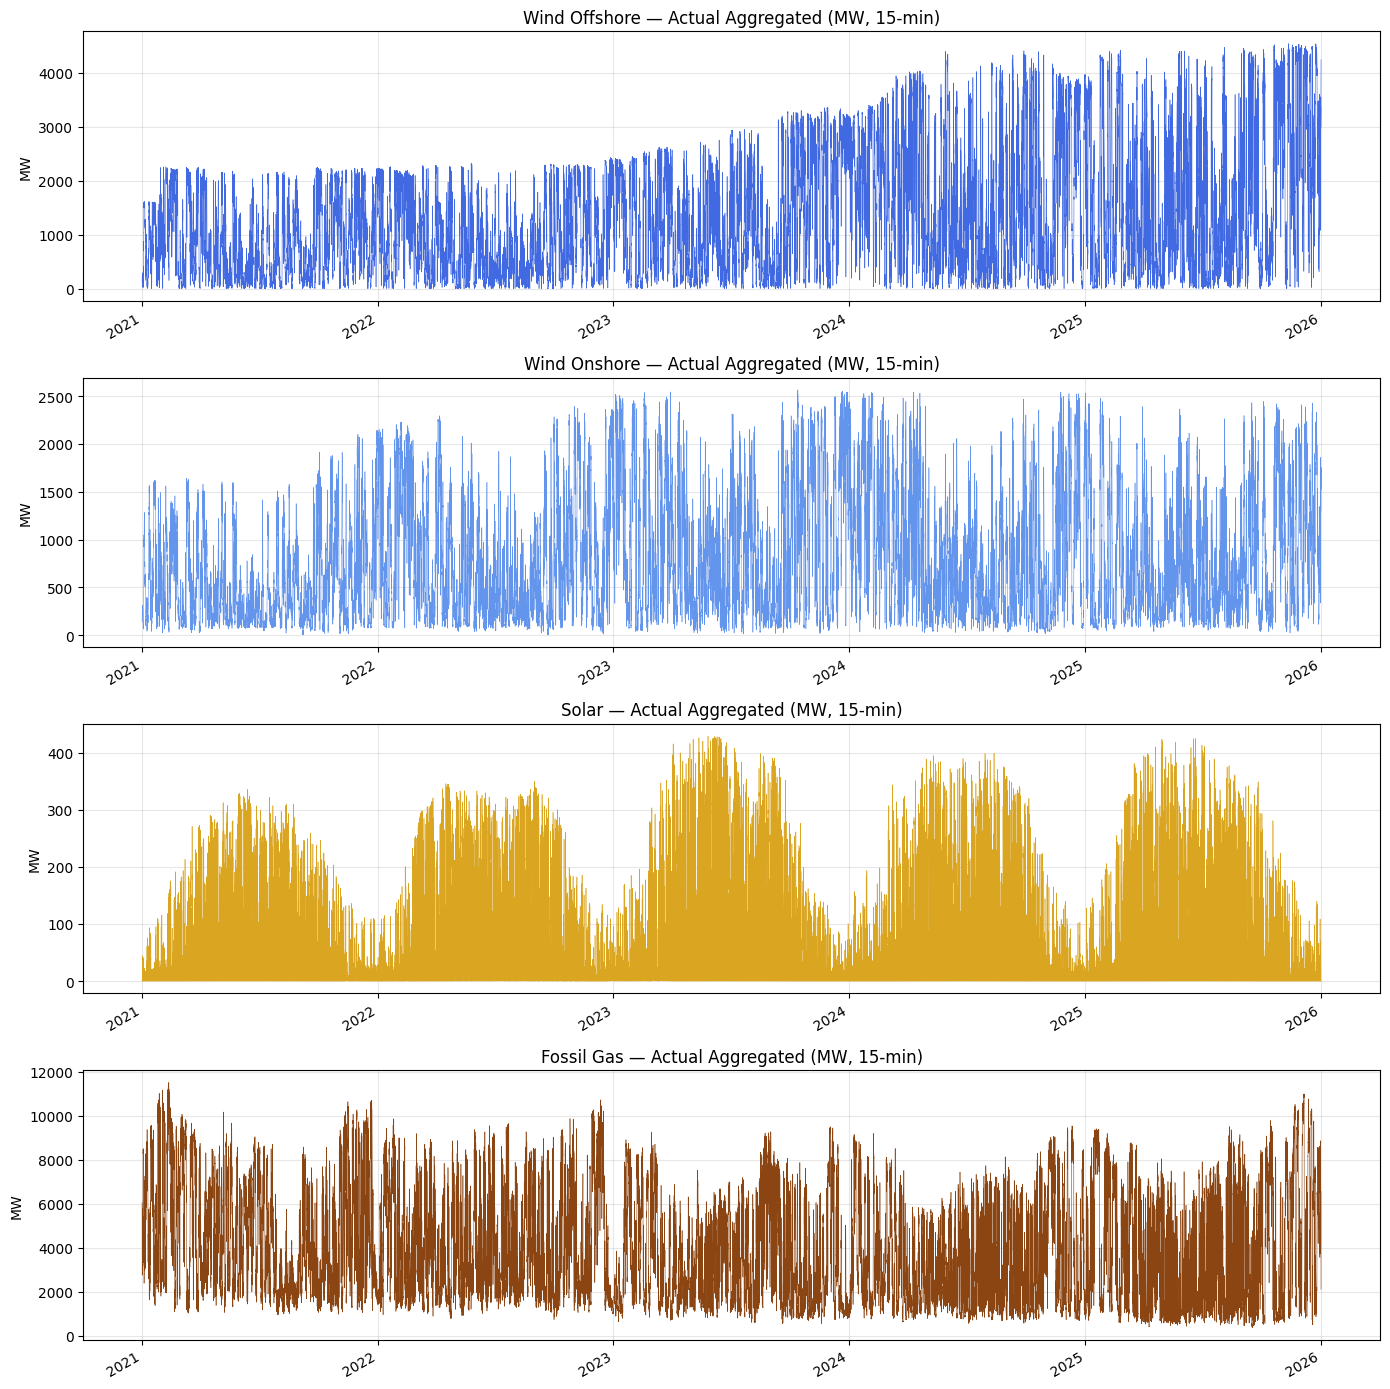

In [20]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# Wind offshore
axes[0].plot(genmix_agg.index, genmix_agg['Wind Offshore'], linewidth=0.4, color='royalblue')
axes[0].set_title('Wind Offshore — Actual Aggregated (MW, 15-min)')
axes[0].set_ylabel('MW')

# Wind onshore
axes[1].plot(genmix_agg.index, genmix_agg['Wind Onshore'], linewidth=0.4, color='cornflowerblue')
axes[1].set_title('Wind Onshore — Actual Aggregated (MW, 15-min)')
axes[1].set_ylabel('MW')

# Solar
axes[2].plot(genmix_agg.index, genmix_agg['Solar'], linewidth=0.4, color='goldenrod')
axes[2].set_title('Solar — Actual Aggregated (MW, 15-min)')
axes[2].set_ylabel('MW')

# Fossil gas (dispatchable, tracks price closely)
axes[3].plot(genmix_agg.index, genmix_agg['Fossil Gas'], linewidth=0.4, color='saddlebrown')
axes[3].set_title('Fossil Gas — Actual Aggregated (MW, 15-min)')
axes[3].set_ylabel('MW')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [21]:
print('Actual Aggregated descriptive statistics (MW):')
display(genmix_agg.describe())

Actual Aggregated descriptive statistics (MW):


,Biomass,Fossil Gas,Fossil Hard coal,Hydro Run-of-river and poundage,Nuclear,Other,Solar,Waste,Wind Offshore,Wind Onshore
count,175296.000000,175296.000000,175296.000000,175296.0,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000
mean,38.523710,3942.804798,1701.421991,0.0,422.342689,3950.844420,55.844367,347.179284,1324.904055,792.462883
std,83.670019,2537.487839,1174.643024,0.0,150.482676,2453.661814,89.453087,53.468514,1129.006333,642.163139
min,0.000000,391.103000,0.000000,0.0,0.000000,55.550000,0.000000,72.680000,0.000000,3.540000
25%,10.440000,1729.990000,686.952500,0.0,467.780000,2288.902500,0.000000,312.136000,359.685000,252.270000
50%,16.290000,3283.025000,1605.335000,0.0,476.660000,3431.853000,0.980000,347.930000,1034.410000,592.975000
75%,28.490000,5894.897500,2727.467500,0.0,484.200000,4899.482500,83.020000,384.120000,2077.317500,1217.040000
max,604.368000,11530.010000,3964.578000,0.0,491.130000,28236.930000,428.770000,517.220000,4537.613000,2565.120000


### Issues — Generation mix

| # | Issue | Action needed |
|---|-------|---------------|
| 1 | Two-row header creates a `MultiIndex` on columns | Use `header=[0, 1]` to load, then keep only `Actual Aggregated` level |
| 2 | CET timezone — same as other ENTSO-E files | Convert to UTC |
| 3 | 15-minute resolution | Resample to hourly mean |
| 4 | `Actual Consumption` columns are mostly zero or sparse (imports/exports) | Drop; keep only `Actual Aggregated` |
| 5 | Fuel type names have spaces and mixed case | Flatten to snake_case: e.g. `wind_offshore`, `fossil_gas` |
| 6 | Some fuel types (e.g. `Hydro Run-of-river`) may have long runs of zeros or NaN (not present in NL) | Decide whether to drop columns with >X% zeros |
| 7 | Index column has no name in the raw CSV | Rename to `datetime_utc` after UTC conversion |

---
## Summary — cleaning tasks before feature engineering

| Dataset | Key actions |
|---------|-------------|
| Day-ahead prices | Concat 5 CSVs, parse UTC index, drop `Country`/`ISO3`/`Datetime (Local)`, localize to UTC |
| Weather | `skiprows=3`, parse UTC index, rename columns to snake_case (drop units) |
| Actual load | Parse CET index → convert to UTC, resample 15min→1h mean |
| Load forecast | Same as actual load; verify date range overlap |
| Generation mix | Two-header load, keep Actual Aggregated only, CET→UTC, 15min→1h mean, snake_case column names |

# Final CREATED files for training and testing

In [ ]:
df = pd.read_parquet("/Data/processed/merged.parquet")
print(df.head())
print(df.dtypes)
print(list(df.columns))

                           price_eur_kwh  temperature_2m  wind_speed_10m_kmh  \
Datetime (UTC)                                                                 
2021-01-01 00:00:00+00:00        0.04819             0.1                 5.9   
2021-01-01 01:00:00+00:00        0.04468             0.6                 6.2   
2021-01-01 02:00:00+00:00        0.04292             0.7                 5.5   
2021-01-01 03:00:00+00:00        0.04039            -0.4                 6.1   
2021-01-01 04:00:00+00:00        0.04020            -0.3                 7.7   

                           wind_speed_100m_kmh  cloud_cover_pct  \
Datetime (UTC)                                                    
2021-01-01 00:00:00+00:00                 13.9               40   
2021-01-01 01:00:00+00:00                 16.6               83   
2021-01-01 02:00:00+00:00                 14.2               54   
2021-01-01 03:00:00+00:00                  9.0               54   
2021-01-01 04:00:00+00:00            

In [ ]:
df1 = pd.read_parquet("/Data/features/features_test.parquet")
print(df1.head())
print(df1.dtypes)
print(list(df1.columns))
print()

                           price_eur_kwh  temperature_2m  wind_speed_10m_kmh  \
Datetime (UTC)                                                                 
2025-01-01 00:00:00+00:00        0.00624             8.5                28.5   
2025-01-01 01:00:00+00:00        0.00416             8.8                29.1   
2025-01-01 02:00:00+00:00        0.00328             9.1                30.0   
2025-01-01 03:00:00+00:00        0.00068             8.9                30.1   
2025-01-01 04:00:00+00:00        0.00000             8.9                30.5   

                           wind_speed_100m_kmh  cloud_cover_pct  \
Datetime (UTC)                                                    
2025-01-01 00:00:00+00:00                 48.3              100   
2025-01-01 01:00:00+00:00                 49.4              100   
2025-01-01 02:00:00+00:00                 50.4              100   
2025-01-01 03:00:00+00:00                 50.7              100   
2025-01-01 04:00:00+00:00            

In [ ]:
df2 = pd.read_parquet("/Data/features/features_train.parquet")
print(df2.head())
print(df2.dtypes)
print(list(df2.columns))

                           price_eur_kwh  temperature_2m  wind_speed_10m_kmh  \
Datetime (UTC)                                                                 
2021-01-01 00:00:00+00:00        0.04819             0.1                 5.9   
2021-01-01 01:00:00+00:00        0.04468             0.6                 6.2   
2021-01-01 02:00:00+00:00        0.04292             0.7                 5.5   
2021-01-01 03:00:00+00:00        0.04039            -0.4                 6.1   
2021-01-01 04:00:00+00:00        0.04020            -0.3                 7.7   

                           wind_speed_100m_kmh  cloud_cover_pct  \
Datetime (UTC)                                                    
2021-01-01 00:00:00+00:00                 13.9               40   
2021-01-01 01:00:00+00:00                 16.6               83   
2021-01-01 02:00:00+00:00                 14.2               54   
2021-01-01 03:00:00+00:00                  9.0               54   
2021-01-01 04:00:00+00:00            

# NA analysis

In [ ]:
train = pd.read_parquet("/Data/features/features_train.parquet")

# Show only rows that have at least one NaN
nan_rows = train[train.isna().any(axis=1)]
print(f"Total rows with NaN: {len(nan_rows)}")
print(f"Date range of NaN rows: {nan_rows.index.min()} → {nan_rows.index.max()}")
print()
print("Which columns have NaN in these rows:")
print(nan_rows.isna().sum())
print()
print("First 10 NaN rows:")
print(nan_rows.head(10)[['price_eur_kwh', 'price_lag_1h', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'price_rolling_std_24h']])

Total rows with NaN: 168
Date range of NaN rows: 2021-01-01 00:00:00+00:00 → 2021-01-07 23:00:00+00:00

Which columns have NaN in these rows:
price_eur_kwh                0
temperature_2m               0
wind_speed_10m_kmh           0
wind_speed_100m_kmh          0
cloud_cover_pct              0
shortwave_radiation_wm2      0
direct_radiation_wm2         0
actual_load_mw               0
load_forecast_mw             0
biomass                      0
fossil_gas                   0
fossil_hard_coal             0
nuclear                      0
other                        0
solar                        0
waste                        0
wind_offshore                0
wind_onshore                 0
price_lag_1h                 1
price_lag_24h               24
price_lag_48h               48
price_lag_168h             168
price_rolling_mean_24h       0
price_rolling_std_24h        1
load_rolling_mean_24h        0
load_rolling_std_24h         1
wind_rolling_mean_24h        0
wind_rolling_std_24h 